# Opioid Deaths: What happened? Why?

In [ ]:
library(coursekata)
library(tidyverse)

# read in and set up data
opioid_data_all <- read.csv("https://docs.google.com/spreadsheets/d/1GQgPUZsVGN8YU4Oxfw5Idbx2BqjD-1SR4UiH3LFNDHc/pub?gid=749944906&single=true&output=csv") %>%
  mutate(year = as.factor(year),
         triplicate = factor(triplicate, levels = c("non-triplicate", "triplicate"), ordered = TRUE)) %>%
  select(state, year, region, low_estimate, population_m, income, pov_rate, triplicate)

# just 3 variables
opioid_long3 <- opioid_data_all %>%
  select(state, year, low_estimate)

# just 5 variables
opioid_long5 <- opioid_data_all %>%
  select(state, year, low_estimate, population_m, pov_rate)

1. Explore the variables in the variable sheet. What do you notice? What do you wonder? What kinds of variables are in the data set? 

## A. What happened to opioid deaths? (From 2000 to 2014)

2. If someone has a hypothesis that we can make a better prediction of opioid related deaths if we knew which year it was (either 2000 or 2014), how would we write this as a function (or a word equation)?

3. Let's make a **scatter plot** (or a **point plot**) to explore this hypothesis. We will use our function to help us with this.

In [ ]:
# fill in the Y and X with the appropriate variables
gf_point(Y ~ X, data = opioid_long3)

4. What do we see in this graph? Is this really a "scatter plot"? Why or why not?

<div class="alert-warning">

**Teacher Note:**

Here you can teach jitter plots by replacing the `gf_point()` with `gf_jitter()`. You may also want to have students adjust the `width` parameter.)
    
Try it in the code cell above. 
</div>

5. What does each dot represent again? 

<div class="alert-warning">

**Teacher Note:**

Follow up questions: 
- Do all of those "cases" change in the same way? 
- Do you think some fo these cases might changed much more than others? Which ones?)

</div>

## B. Prediction: Which states *do you think* had an explosion of opioid-related deaths? 

6. Let's *filter* the data to zero in on particular states that you suspect had growth in opioid-related deaths. Before you run the code, predict what you think the code will do. 

Remove the `#` and run it. Did it do what you predicted? 

Edit it to explore a different state (confer with your neighbors and pick different states).

In [ ]:
# Modify this to explore the state you are interested in
filter(opioid_long3, state == "Alabama")

7. Let's see where your state is in the jitter plot. Edit the code below to color your state in a different color.

In [ ]:
# Modify this to explore the state you are interested in
gf_jitter(low_estimate ~ year, data = opioid_long3, width = .2,
  color = ~(state == "Alabama"))

8. Compare your state with someone sitting near you. 
- What similarities and differences do you see in your states? 
- Who's state saw the biggest change in opioid deaths from 2000 to 2014? 
- Why do you think that might be? 

In [ ]:
# This slightly advanced plot draws lines for each state
gf_point(low_estimate ~ year, data = opioid_long3,
  alpha = ~(state == "Alabama")) %>%
  gf_line(group = ~state, alpha = .1) 

## C. Change in Opioid Deaths: From Long to Wide Data

Before we were interested in year as a part of our function (**low_estimate = f(year) + other stuff**). 

### Sketch New Data

See handout.

### Pivot by Hand

See handout.

### From Code to Table

See handout.

In [ ]:
# Run this 
opioid_wide <- pivot_wider(opioid_long3,
                 names_from = year,
                 values_from = low_estimate,
                 names_prefix = "low_estimate_")
opioid_wide <- mutate(opioid_wide,
                 change = low_estimate_2014 - low_estimate_2000)

head(opioid_wide)

## D. What happens to the other columns?

See handout.

In [ ]:
# Run this 
pivot_wider(opioid_long5,
  names_from = year,
  values_from = low_estimate,
  names_prefix = "low_estimate_") %>%
head()


## E. Exploring the Wide Data

9. We made a wide data set for you that includes some other variables. Run the code below and compare it to the `opioid_wide` you made. 
- What does a row represent here?
- What decision did we make about `population_m` and `pov_rate`?

In [ ]:
# Run this
opioid_wide <- read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTh09LcHDe6KuEtnv4BqPQZutcvf8OlOoMrUF3Z81H-XTlrcS9IzIAaJc1_YUb6X1Z0uIyIgEV8wO87/pub?gid=1534502554&single=true&output=csv") %>%
  select(state, region, low_estimate_2000, low_estimate_2014, change, population_m, pov_rate, pres16, triplicate)

head(opioid_wide)

10. What kinds of states experienced the most (or least) change in opioid related deaths? What do those states have in common? 

In [ ]:
# Write code


## F. Plot Twist: Let's talk about Purdue Pharma

Oxycontin, developed by Purdue Pharma, first came out in 1996. How was it originally marketed? Let's take a moment to watch this old commercial: https://www.youtube.com/watch?v=LaxlJXpwkzs )

The images below are real marketing recommendations about how and where to market Oxycontin. 

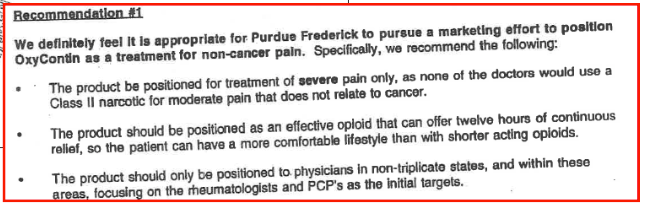

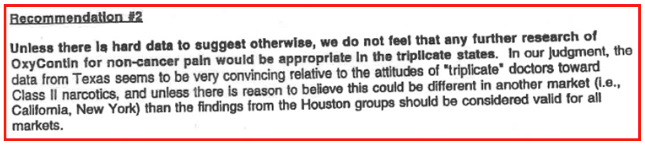

11. Purdue decided to not to advertise oxycontin to doctors in which states?


<div class="alert-warning">

**What's a triplicate?**

In these states, whenever a doctor prescribed opioids, the prescription form automatically made 3 copies: 

1. one stayed in the doctor's office, 
2. another went to the pharmacist, and 
3. another got sent to the state government. 

All of this extra paperwork was to track who was prescribing opioids and filling those prescriptions.

</div>
 

12. What's your hypothesis? 

In [ ]:
# Make a plot to explore this hypothesis
